# 02 — Feature Engineering
### 2023/24 Kenya Housing Survey · MSc Dissertation
**Strathmore University · Data Science & Analytics**

Constructs the **Housing Financial Vulnerability Score (HFVS)** from five dimensions:

| # | Dimension | Source file(s) |
|---|-----------|---------------|
| D1 | Financial stress | Household (c14_1, k05, c14_2) |
| D2 | Tenure insecurity | Household (i00, k02, k29, k34, k35) |
| D3 | Physical hazard | Household (e06, e07, e09__1–13) — enumerator-observed |
| D4 | Dwelling quality | Dwelling Units (d14, d15, d16, d08, d09) |
| D5 | Utility deprivation | Household (c08, c01_1, c04, c11) |

**Key facts from notebook 01:**
- Dwelling joins at 100%, Individual joins at 100%
- Mortgage/Loan use a different join key — use household-level finance flags instead
- County file joins on `cg00`, not `countycode`
- d13 (persons/dwelling) is 72.7% null — use `a12` from household for overcrowding
- Total weighted population: 13,886,126 households

**Output:** `master_hfvs.parquet` saved to Google Drive

---
## 1. Environment Setup

In [42]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.


In [43]:
!pip install -q polars pyarrow scikit-learn matplotlib seaborn scipy

In [44]:
import json, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────
DRIVE  = Path("/content/drive/MyDrive/KHS_Dissertation")
PQ     = DRIVE / "data" / "parquet"
FIGS   = DRIVE / "outputs" / "figures"
TABLES = DRIVE / "outputs" / "tables"
for p in [FIGS, TABLES]: p.mkdir(parents=True, exist_ok=True)

# ── Plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '500', 'axes.labelsize': 11,
})
TEAL   = '#00695C'; PURPLE = '#6A1B9A'; AMBER = '#E65100'
RED    = '#B71C1C'; BLUE   = '#1565C0'; GRAY  = '#546E7A'

# ── Codebooks ──────────────────────────────────────────────────────────
with open(PQ / 'household_variable_labels.json') as f:
    HH_VAR  = json.load(f)
with open(PQ / 'household_value_labels.json') as f:
    HH_VAL  = json.load(f)
with open(PQ / 'dwelling_variable_labels.json') as f:
    DW_VAR  = json.load(f)
with open(PQ / 'dwelling_value_labels.json') as f:
    DW_VAL  = json.load(f)
with open(PQ / 'individual_variable_labels.json') as f:
    IND_VAR = json.load(f)

# File registry (exact names confirmed in notebook 01)
FILES = {
    'household':  'Household_Information_Data.parquet',
    'individual': 'Individual_Data.parquet',
    'dwelling':   'Dwelling_Units_Data.parquet',
    'county':     'County_Physical_Planning_Data.parquet',
}

print("Environment ready.")

Environment ready.


---
## 2. Load & Inspect Raw Files

In [45]:
# ── Household spine ────────────────────────────────────────────────────
hh = pl.read_parquet(PQ / FILES['household']).to_pandas()
print(f"Household:  {hh.shape[0]:,} rows × {hh.shape[1]} cols")

# ── Dwelling units ─────────────────────────────────────────────────────
dw = pl.read_parquet(PQ / FILES['dwelling']).to_pandas()
print(f"Dwelling:   {dw.shape[0]:,} rows × {dw.shape[1]} cols")
# Dwelling has more rows than household — multiple dwelling units per hh
# Strategy: aggregate to 1 row per interview__key (take the primary dwelling)
print(f"  Unique interview__key in dwelling: {dw['interview__key'].nunique():,}")
print(f"  Max dwellings per household: {dw.groupby('interview__key').size().max()}")

# ── Individual microdata ───────────────────────────────────────────────
# Load full file — 80,889 rows, 97 cols, 2.87 MB parquet (fast)
ind = pl.read_parquet(PQ / FILES['individual']).to_pandas()
print(f"Individual: {ind.shape[0]:,} rows × {ind.shape[1]} cols")
print(f"  Unique interview__key in individual: {ind['interview__key'].nunique():,}")

Household:  21,347 rows × 392 cols
Dwelling:   25,116 rows × 25 cols
  Unique interview__key in dwelling: 21,354
  Max dwellings per household: 7
Individual: 80,889 rows × 97 cols
  Unique interview__key in individual: 21,347


---
## 3. Decode Material Codes
The dwelling file stores floor (d14), wall (d15), roof (d16) as numeric codes.
We map each to a **durability tier** using WHO/KNBS housing standards.

In [46]:
# ── Durability classification maps ─────────────────────────────────────
# Based on KNBS/UN-Habitat housing standards:
# Durable = permanent materials (concrete, brick, iron sheets, tiles)
# Non-durable = temporary/informal materials (earth, wood, grass, plastic)
#
# Adjust code sets below after reviewing the printed labels above.
# Default values are informed by KHS questionnaire structure.

# FLOOR: codes for durable (cement, tiles, concrete, terrazzo)
FLOOR_DURABLE = {1.0, 2.0, 8.0, 9.0}   # cement/concrete/tiles/terrazzo
# Non-durable: earth/sand (3), wood planks (5,6), other (7) — confirm from labels

# WALL: codes for durable (brick, stone, concrete, metal)
WALL_DURABLE  = {4.0, 5.0, 10.0, 11.0, 12.0, 13.0}  # brick/block/concrete/stone
# Non-durable: wood (2), bamboo (3), grass/reeds (6), earth/mud (7,8,9), plastic (14,15)

# ROOF: codes for durable (iron sheets, concrete, tiles)
# CONFIRMED classification for d16
ROOF_DURABLE     = {3.0, 5.0, 6.0, 7.0}   # iron sheets, asbestos, concrete, tiles
ROOF_NON_DURABLE = {1.0, 2.0, 4.0, 8.0}   # grass/thatch, dung/mud, tin cans, canvas/cardboard

#ROOF_DURABLE  = {1.0, 3.0, 4.0, 5.0}   # concrete/iron sheets/tiles
# Non-durable: grass/thatch (2,6), plastic (7), leaves (8)


print("Durability maps defined.")
print("NOTE: Run the cell above first to confirm code-label mapping.")
print("      Adjust FLOOR_DURABLE, WALL_DURABLE, ROOF_DURABLE if needed.")

Durability maps defined.
NOTE: Run the cell above first to confirm code-label mapping.
      Adjust FLOOR_DURABLE, WALL_DURABLE, ROOF_DURABLE if needed.


In [47]:
# Print value labels for material columns so we can map them
print("=== FLOOR MATERIAL (d14) ===")
for k, v in DW_VAL.get('D14', DW_VAL.get('d14', {})).items():
    count = (dw['d14'] == float(k)).sum() if k.replace('.','').isdigit() else 0
    print(f"  {k:>4} → {v:<35} n={count:,}")

print("\n=== WALL MATERIAL (d15) ===")
for k, v in DW_VAL.get('D15', DW_VAL.get('d15', {})).items():
    count = (dw['d15'] == float(k)).sum() if k.replace('.','').isdigit() else 0
    print(f"  {k:>4} → {v:<35} n={count:,}")

print("\n=== ROOF MATERIAL (d16) ===")
for k, v in DW_VAL.get('D16', DW_VAL.get('d16', {})).items():
    count = (dw['d16'] == float(k)).sum() if k.replace('.','').isdigit() else 0
    print(f"  {k:>4} → {v:<35} n={count:,}")

=== FLOOR MATERIAL (d14) ===
     1 → Earth/sand                          n=8,179
     2 → Dung                                n=2,204
     3 → Wood planks/shingles/timber         n=76
     4 → Palm/ bamboo                        n=4
     5 → Parquet or polished wood            n=26
     6 → Vinyl or asphalt strips             n=75
     7 → Ceramic tiles                       n=3,106
     8 → Concrete/ Cement/Terrazo            n=11,269
     9 → Wall to wall Carpet                 n=170
    96 → Other                               n=7

=== WALL MATERIAL (d15) ===
     1 → No walls                            n=20
     2 → Cane/palm/trunks                    n=706
     3 → Grass/reeds                         n=478
     4 → Mud/cow dung                        n=5,806
     5 → Bamboo with mud                     n=1,068
     6 → Stone with mud                      n=358
     7 → Uncovered adobe                     n=335
     8 → Plywood/Cardboard                   n=40
     9 → Reused wood

---
## 4. Aggregate Individual File → Household Level

In [48]:
# Print individual codebook to find education and employment columns
print("Individual file — education and employment columns:")
econ_kw = ['edu', 'employ', 'work', 'school', 'age', 'sex', 'gender',
           'occupation', 'earn', 'income', 'literate', 'read', 'disability']
for col, lbl in IND_VAR.items():
    if any(k in col.lower() or k in lbl.lower() for k in econ_kw):
        nn = ind[col].notna().sum() if col in ind.columns else '—'
        print(f"  {col:<25} → {lbl[:65]}  [{nn}]")

Individual file — education and employment columns:
  b04                       → Sex  [80889]
  b05_years                 → Age_years  [80889]
  age_cur                   → Current age calculated from DOB  [80835]
  b08_6                     → communicating using his/her usual  language for example understan  [80889]
  b10                       → B10:Has [NAME] ever attended school?  [75155]
  b11                       → B11:Is [NAME] currently attending School/ Academic institution?  [63868]
  b13                       → B13:What  is the highest education level completed  [63381]
  b13_other                 → B13_Other:What  is the highest education level completed  [80889]
  b13_2                     → B13_2:Mode of transport used to school  [22700]
  b13_2_other               → B13_2_Other:Mode of transport used to school  [80889]
  dif_comm                  → communicating using his/her usual  language for example understan  [80889]
  dsb_details               → Disability status 

In [49]:
# ── Aggregate to household level ───────────────────────────────────────
# Adjust column names below based on the output of the cell above

age_col = 'age_cur'  # confirm from above

# Determine the best employment and education columns from inspection above
# Common pattern in KHS: b09_1 = currently working (1=yes), b08_1 = highest education
# Update these after running the inspection cell
EMPLOY_COL = 'b09_1'   # ← update if different: 1=employed, else=not
# EDU_COL    = 'b08_1'   # ← update if different: higher code = more education
# WRONG — raw questionnaire code

# CORRECT — confirmed from codebook
EDU_COL = 'ken_edu_isced11'

ind['age_n']    = pd.to_numeric(ind[age_col], errors='coerce')
ind['employed'] = pd.to_numeric(ind.get(EMPLOY_COL, pd.Series(dtype=float)), errors='coerce')
ind['edu_level']= pd.to_numeric(ind.get(EDU_COL,    pd.Series(dtype=float)), errors='coerce')

ind_agg = (
    ind.groupby('interview__key', as_index=False)
       .agg(
           # Household size (ground truth from individual records)
           ind_hh_size     = ('interview__key', 'count'),

           # Age structure
           mean_age        = ('age_n', 'mean'),
           n_children      = ('age_n', lambda x: (x < 15).sum()),
           n_elderly       = ('age_n', lambda x: (x >= 65).sum()),
           n_working_age   = ('age_n', lambda x: ((x >= 15) & (x < 65)).sum()),

           # Employment
           n_employed      = ('employed', lambda x: (x == 1).sum()),

           # Education (highest attained in household)
           max_edu         = ('edu_level', 'max'),
           mean_edu        = ('edu_level', 'mean'),
       )
)

# Derived ratios
ind_agg['dependency_ratio'] = (
    (ind_agg['n_children'] + ind_agg['n_elderly']) /
    ind_agg['n_working_age'].replace(0, np.nan)
)
ind_agg['employment_rate'] = (
    ind_agg['n_employed'] / ind_agg['ind_hh_size']
)

print(f"Individual aggregation: {len(ind_agg):,} household-level rows")
print(ind_agg[['ind_hh_size','mean_age','dependency_ratio','employment_rate','max_edu']].describe().round(2))

Individual aggregation: 21,347 household-level rows
       ind_hh_size  mean_age  dependency_ratio  employment_rate   max_edu
count     21347.00  21340.00          20310.00         21347.00  21347.00
mean          3.79     29.41              0.76             0.01     10.49
std           2.25     29.97              0.89             0.10      5.22
min           1.00  -2488.25              0.00             0.00      2.00
25%           2.00     19.20              0.00             0.00      6.00
50%           4.00     25.00              0.50             0.00      8.00
75%           5.00     35.00              1.00             0.00     16.00
max          18.00   2024.00              8.00             1.00     16.00


---
## 5. Aggregate Dwelling File → Household Level
25,116 dwelling records → 21,347 households (some have >1 dwelling unit).
Strategy: keep the row with `d12 == 1` (primary/owned) if it exists, else first row.

In [50]:
# Sort so d12==1 (own) comes first, then take first row per household
dw_sorted = dw.sort_values(['interview__key', 'd12'], ascending=[True, True])
dw_primary = dw_sorted.groupby('interview__key', as_index=False).first()

print(f"Dwelling aggregated: {len(dw_primary):,} rows (one per household)")
print(f"d12 (tenure) distribution in primary dwelling:")
print(dw_primary['d12'].value_counts())
# Check material null rates
for col in ['d14', 'd15', 'd16', 'd08', 'd09']:
    pct = dw_primary[col].isna().mean() * 100
    print(f"  {col}: {pct:.1f}% null")

Dwelling aggregated: 21,354 rows (one per household)
d12 (tenure) distribution in primary dwelling:
d12
1    13168
2     6938
3     1035
4      213
Name: count, dtype: int64
  d14: 0.0% null
  d15: 0.0% null
  d16: 0.0% null
  d08: 0.0% null
  d09: 0.0% null


---
## 6. Build the Master Dataset
Join household (spine) ← dwelling ← individual aggregates

In [51]:
# ── Step 1: Join dwelling to household ────────────────────────────────
dw_cols = ['interview__key', 'd03', 'd04', 'd05', 'd06', 'd07',
           'd08', 'd08_1', 'd09', 'd10', 'd11_1', 'd12',
           'd14', 'd15', 'd16']
dw_cols = [c for c in dw_cols if c in dw_primary.columns]

master = hh.merge(dw_primary[dw_cols], on='interview__key', how='left', suffixes=('', '_dw'))
print(f"After dwelling join: {master.shape}")

# ── Step 2: Join individual aggregates ────────────────────────────────
master = master.merge(ind_agg, on='interview__key', how='left')
print(f"After individual join: {master.shape}")

# ── Step 3: Use a12 (household persons) where ind_hh_size may differ ──
master['hh_size'] = pd.to_numeric(master['a12'], errors='coerce')
master['hh_size'] = master['hh_size'].fillna(master.get('ind_hh_size', np.nan))

print(f"\nMaster dataset: {master.shape[0]:,} rows × {master.shape[1]} cols")
print(f"Household size: median={master['hh_size'].median():.1f}, mean={master['hh_size'].mean():.2f}")

After dwelling join: (21347, 406)
After individual join: (21347, 416)

Master dataset: 21,347 rows × 417 cols
Household size: median=4.0, mean=3.79


In [52]:
# ── Inspect key individual columns before aggregating ──────────────────
# Age
age_col = 'age_cur' if 'age_cur' in ind.columns else 'b05_years'
print(f"Age column: {age_col}")
age = pd.to_numeric(ind[age_col], errors='coerce')
print(age.describe().round(1))

# Sex — find the column
sex_col = 'b06' if 'b06' in ind.columns else None
if sex_col:
    print(f"\nSex (b06) distribution:")
    print(ind[sex_col].value_counts())

# Education — b08 block
edu_cols = [c for c in ind.columns if c.startswith('b08')]
print(f"\nEducation columns: {edu_cols}")
for c in edu_cols[:4]:
    print(f"\n{c} → {IND_VAR.get(c,'?')}")
    print(ind[c].value_counts().head(6))


# Employment — b09 block
emp_cols = [c for c in ind.columns if c.startswith('b09')]
print(f"\nEmployment columns: {emp_cols}")
for c in emp_cols[:3]:
    print(f"\n{c} → {IND_VAR.get(c,'?')}")
    print(ind[c].value_counts().head(5))

Age column: age_cur
count    80835.0
mean        25.1
std         54.5
min      -9998.0
25%         10.0
50%         20.0
75%         37.0
max       2024.0
Name: age_cur, dtype: float64

Sex (b06) distribution:
b06
1.0    24675
6.0    18947
5.0     3355
3.0     2173
2.0     1619
4.0      620
Name: count, dtype: int64

Education columns: ['b08_1', 'b08_2', 'b08_3', 'b08_4', 'b08_5', 'b08_6']

b08_1 → have difficulty seeing
b08_1
1    76083
2     3968
3      695
4      143
Name: count, dtype: int64

b08_2 → hearing, even if using hearing aid?
b08_2
1    78880
2     1538
3      325
4      146
Name: count, dtype: int64

b08_3 → walking or climbing steps?
b08_3
1    77486
2     2291
3      875
4      237
Name: count, dtype: int64

b08_4 → remembering or concentrating?
b08_4
1    79153
2     1168
3      413
4      155
Name: count, dtype: int64

Employment columns: ['b09_1', 'b09_2', 'b09_3', 'b09_4', 'b09_5', 'b09_6', 'b09_7', 'b09_7other']

b09_1 → B09_1:County of birth
b09_1
9.0     2859
8

---
## 7. Dimension 1 — Financial Stress

In [53]:
# ── 7.1 Winsorise and validate input columns ───────────────────────────
def winsorise(series, lo=0.01, hi=0.99):
    """Clip to [lo, hi] percentiles, ignoring nulls."""
    s = pd.to_numeric(series, errors='coerce')
    p_lo, p_hi = s.quantile([lo, hi])
    return s.clip(p_lo, p_hi)

master['expenditure']  = winsorise(master['c14_1'])
master['savings']      = winsorise(master['c14_2'])
master['investments']  = winsorise(master['c14_3'])
master['monthly_rent'] = winsorise(master['k05'])

# Coverage check
for col, name in [('expenditure','Monthly expenditure'),
                  ('monthly_rent','Monthly rent'),
                  ('savings','Monthly savings')]:
    nn = master[col].notna().sum()
    print(f"{name}: {nn:,} non-null ({nn/len(master)*100:.1f}%)  "
          f"median={master[col].median():,.0f}  mean={master[col].mean():,.0f}")

Monthly expenditure: 21,346 non-null (100.0%)  median=10,000  mean=12,044
Monthly rent: 6,932 non-null (32.5%)  median=3,000  mean=4,302
Monthly savings: 21,346 non-null (100.0%)  median=0  mean=1,657


In [54]:
# ── 7.2 Rent burden ratio (renters only) ──────────────────────────────
# Structural note: k05 is only answered by renters (by survey design).
# Owners get l15 (estimated rental value) — use for owners' burden proxy.

# Renter rent burden
mask_renter = master['monthly_rent'].notna() & master['expenditure'].notna() & \
              (master['monthly_rent'] > 0) & (master['expenditure'] > 0)
master.loc[mask_renter, 'rent_burden'] = (
    master.loc[mask_renter, 'monthly_rent'] / master.loc[mask_renter, 'expenditure']
).clip(0, 1)

# Owner imputed burden (l15 = estimated rent they could charge → affordability proxy)
if 'l15' in master.columns:
    l15 = winsorise(master['l15'])
    mask_owner = master['rent_burden'].isna() & l15.notna() & master['expenditure'].notna() & \
                 (l15 > 0) & (master['expenditure'] > 0)
    master.loc[mask_owner, 'rent_burden'] = (
        l15[mask_owner] / master.loc[mask_owner, 'expenditure']
    ).clip(0, 1)

# For households with no rent data: impute with county-residence median
county_res_medians = (
    master.groupby(['a01', 'a07_1'])['rent_burden']
          .transform('median')
)
master['rent_burden'] = master['rent_burden'].fillna(county_res_medians)
master['rent_burden'] = master['rent_burden'].fillna(master['rent_burden'].median())

# Binary flags
master['rent_stressed']       = (master['rent_burden'] > 0.30).astype(float)
master['severely_stressed']   = (master['rent_burden'] > 0.50).astype(float)
master['no_savings']          = (master['savings'].fillna(0) == 0).astype(float)
master['low_income_flag']     = pd.to_numeric(master.get('d20__8', 0), errors='coerce').fillna(0)
master['no_loan_access']      = pd.to_numeric(master.get('d20__4', 0), errors='coerce').fillna(0)

print(f"Rent burden computed for {master['rent_burden'].notna().sum():,} households")
print(f"  Rent-stressed (>30%):          {master['rent_stressed'].mean()*100:.1f}%")
print(f"  Severely stressed (>50%):      {master['severely_stressed'].mean()*100:.1f}%")
print(f"  No savings:                    {master['no_savings'].mean()*100:.1f}%")
print(f"  Report low income barrier:     {master['low_income_flag'].mean()*100:.1f}%")
print(f"  Don't qualify for loan:        {master['no_loan_access'].mean()*100:.1f}%")

Rent burden computed for 21,347 households
  Rent-stressed (>30%):          54.8%
  Severely stressed (>50%):      30.6%
  No savings:                    57.4%
  Report low income barrier:     13.1%
  Don't qualify for loan:        0.6%


In [55]:
# ── 7.3 Financial stress score (D1) ───────────────────────────────────
# Scale rent_burden 0–1, then combine with binary flags
rb_norm = MinMaxScaler().fit_transform(master[['rent_burden']]).flatten()
master['d1_financial_stress'] = (
    0.50 * rb_norm                        +  # rent burden dominates
    0.20 * master['no_savings']           +
    0.15 * master['low_income_flag']      +
    0.15 * master['no_loan_access']
).clip(0, 1)

print(f"D1 Financial Stress: mean={master['d1_financial_stress'].mean():.3f}  "
      f"std={master['d1_financial_stress'].std():.3f}")
print(master['d1_financial_stress'].describe().round(3))

D1 Financial Stress: mean=0.356  std=0.184
count    21347.000
mean         0.356
std          0.184
min          0.000
25%          0.231
50%          0.339
75%          0.500
max          1.000
Name: d1_financial_stress, dtype: float64


---
## 8. Dimension 2 — Tenure Insecurity

In [56]:
# Print value labels for tenure columns to confirm codes
for col in ['i00', 'k02', 'k29', 'k34', 'k35']:
    label_dict = HH_VAL.get(col.upper(), HH_VAL.get(col, {}))
    nn = master[col].notna().sum() if col in master.columns else 0
    vc = master[col].value_counts().to_dict() if col in master.columns else {}
    print(f"{col}: {HH_VAR.get(col,'?')[:60]}")
    print(f"  labels: {label_dict}")
    print(f"  values: {vc}  ({nn:,} non-null)")

i00: I00: Ownership of Land
  labels: {'0': 'No', '1': 'Yes'}
  values: {0.0: 11639, 1.0: 9707}  (21,346 non-null)
k02: Do you have a written  Agreement/Contract with your landlord
  labels: {'1': 'Yes', '2': 'No'}
  values: {2.0: 5383, 1.0: 1562}  (6,945 non-null)
k29: K29Have you ever had a rent dispute with a landlord/Agent?
  labels: {'0': 'No', '1': 'Yes'}
  values: {0.0: 6476, 1.0: 469}  (6,945 non-null)
k34: K34Have there been any house demolitions in your neighbourho
  labels: {'0': 'No', '1': 'Yes'}
  values: {0.0: 6634, 1.0: 311}  (6,945 non-null)
k35: K35:threats of your household being evicted
  labels: {'0': 'No', '1': 'Yes'}
  values: {0.0: 6772, 1.0: 173}  (6,945 non-null)


In [57]:
# ── 8.1 Tenure flags ───────────────────────────────────────────────────
# After inspecting labels above, adjust the "insecure" codes accordingly.
# Defaults assume 1=yes for binary questions, i00: 0=does not own land.

def safe_flag(col, insecure_codes, df=master):
    """Return 1 where column value is in insecure_codes, 0 otherwise."""
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index)
    s = pd.to_numeric(df[col], errors='coerce')
    return s.isin(insecure_codes).astype(float).where(s.notna(), np.nan)

# i00: land ownership. Assume 1=Yes (owns), 2=No → insecure = {2}
# Adjust {2} if value labels show different coding
master['no_land_ownership'] = safe_flag('i00', {2.0})

# k02: written tenancy agreement. Assume 2=No → insecure
master['no_written_lease']  = safe_flag('k02', {2.0})

# k29: ever had rent dispute. 1=Yes → insecure
master['rent_dispute_hist'] = safe_flag('k29', {1.0})

# k34: demolitions in neighbourhood. 1=Yes → insecure
master['demo_neighbourhood']= safe_flag('k34', {1.0})

# k35: eviction threat. 1=Yes → insecure
master['eviction_threat']   = safe_flag('k35', {1.0})

# l26: demolition threat (owners). 1=Yes → insecure
master['demo_threat']       = safe_flag('l26', {1.0})

tenure_flags = ['no_land_ownership','no_written_lease','rent_dispute_hist',
                'demo_neighbourhood','eviction_threat','demo_threat']

print("Tenure insecurity flags:")
for f in tenure_flags:
    pct = master[f].mean() * 100 if master[f].notna().sum() > 0 else 0
    nn  = master[f].notna().sum()
    print(f"  {f:<25} {pct:>5.1f}% insecure  [{nn:,} non-null]")

Tenure insecurity flags:
  no_land_ownership           0.0% insecure  [21,346 non-null]
  no_written_lease           77.5% insecure  [6,945 non-null]
  rent_dispute_hist           6.8% insecure  [6,945 non-null]
  demo_neighbourhood          4.5% insecure  [6,945 non-null]
  eviction_threat             2.5% insecure  [6,945 non-null]
  demo_threat                 1.3% insecure  [13,160 non-null]


In [58]:
# ── 8.2 Tenure insecurity score (D2) ──────────────────────────────────
# Fill nulls with 0 (conservative — assume secure if not reported)
# Weight eviction_threat and no_land_ownership more heavily

for f in tenure_flags:
    master[f] = master[f].fillna(0)

master['d2_tenure_insecurity'] = (
    0.30 * master['no_land_ownership']   +
    0.25 * master['eviction_threat']     +
    0.20 * master['no_written_lease']    +
    0.10 * master['rent_dispute_hist']   +
    0.10 * master['demo_neighbourhood']  +
    0.05 * master['demo_threat']
).clip(0, 1)

print(f"D2 Tenure Insecurity: mean={master['d2_tenure_insecurity'].mean():.3f}  "
      f"std={master['d2_tenure_insecurity'].std():.3f}")
print(master['d2_tenure_insecurity'].describe().round(3))

D2 Tenure Insecurity: mean=0.057  std=0.100
count    21347.000
mean         0.057
std          0.100
min          0.000
25%          0.000
50%          0.000
75%          0.200
max          0.650
Name: d2_tenure_insecurity, dtype: float64


---
## 9. Dimension 3 — Physical Hazard
All enumerator-observed — highest data quality in the survey.

In [59]:
# ── 9.1 Confirm e06, e07 coding ───────────────────────────────────────
for col in ['e06', 'e07']:
    lbl = HH_VAL.get(col.upper(), HH_VAL.get(col, {}))
    print(f"{col} → {HH_VAR.get(col,'?')}")
    print(f"  labels: {lbl}")
    print(f"  values: {master[col].value_counts().to_dict()}\n")

# Proximity labels
PROX_LABELS = {
    'e09__1':'River/Lake', 'e09__2':'Swamp', 'e09__3':'Wetland',
    'e09__4':'Quarry',     'e09__5':'Dumpsite', 'e09__6':'Factory',
    'e09__7':'Forest',     'e09__8':'Bars/Nightlife', 'e09__9':'Worship',
    'e09__10':'Airport',   'e09__11':'Busy road', 'e09__12':'Helipad',
    'e09__13':'Ocean'
}
# High-risk subset (negative environmental impact)
HIGH_RISK_PROX = ['e09__2','e09__5','e09__6','e09__11']  # swamp, dumpsite, factory, busy road

e06 → E06:Is your locality prone to flooding
  labels: {'0': 'No', '1': 'Yes, Severe', '2': 'Yes, Mild'}
  values: {0.0: 17274, 2.0: 2678, 1.0: 1394}

e07 → E07:Is your locality prone to fmudslides
  labels: {'0': 'No', '1': 'Yes, Severe', '2': 'Yes, Mild'}
  values: {0.0: 18660, 2.0: 1817, 1.0: 869}



In [60]:
# ── 9.2 Build hazard features ─────────────────────────────────────────
# Flood/mudslide: binary flags (1=yes, 2=no in KHS — confirm from cell above)
# Adjust insecure_codes after checking actual labels
master['flood_zone']    = safe_flag('e06', {1.0})
master['mudslide_zone'] = safe_flag('e07', {1.0})

# Count of proximity hazards present
prox_cols = [c for c in PROX_LABELS.keys() if c in master.columns]
prox_data = master[prox_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
master['hazard_count']  = prox_data.sum(axis=1)

# High-risk proximity flag (any of the four high-risk types)
high_risk_present = [c for c in HIGH_RISK_PROX if c in master.columns]
master['high_risk_prox'] = (
    master[high_risk_present].apply(pd.to_numeric, errors='coerce')
                              .max(axis=1).fillna(0)
)

for f in ['flood_zone','mudslide_zone','high_risk_prox']:
    master[f] = master[f].fillna(0)

# ── 9.3 Physical hazard score (D3) ────────────────────────────────────
hazard_count_norm = MinMaxScaler().fit_transform(
    master[['hazard_count']]
).flatten()

master['d3_physical_hazard'] = (
    0.35 * master['flood_zone']    +
    0.25 * master['mudslide_zone'] +
    0.25 * master['high_risk_prox']+
    0.15 * hazard_count_norm
).clip(0, 1)

print(f"D3 Physical Hazard: mean={master['d3_physical_hazard'].mean():.3f}  "
      f"std={master['d3_physical_hazard'].std():.3f}")
print(f"  Flood zones:      {master['flood_zone'].mean()*100:.1f}% of households")
print(f"  Mudslide zones:   {master['mudslide_zone'].mean()*100:.1f}% of households")
print(f"  High-risk prox:   {master['high_risk_prox'].mean()*100:.1f}% of households")

D3 Physical Hazard: mean=0.134  std=0.178
  Flood zones:      6.5% of households
  Mudslide zones:   4.1% of households
  High-risk prox:   30.0% of households


---
## 10. Dimension 4 — Dwelling Quality

In [61]:
# ── 10.1 Confirm material classifications ─────────────────────────────
# Run this cell to validate your durability maps from Section 3
for col, durable_set, name in [
    ('d14', FLOOR_DURABLE, 'Floor'),
    ('d15', WALL_DURABLE,  'Wall'),
    ('d16', ROOF_DURABLE,  'Roof'),
]:
    val_map = DW_VAL.get(col.upper(), DW_VAL.get(col, {}))
    col_data = pd.to_numeric(master[col], errors='coerce')
    pct_durable = col_data.isin(durable_set).mean() * 100
    print(f"\n{name} material ({col}): {pct_durable:.1f}% classified as durable")
    for code in sorted(col_data.dropna().unique()):
        label_str = val_map.get(str(int(code)), '?')
        n = (col_data == code).sum()
        dur = '✓ durable' if code in durable_set else '✗ non-durable'
        print(f"  {code:>4.0f} → {label_str:<35} n={n:,}  {dur}")


Floor material (d14): 85.4% classified as durable
     1 → Earth/sand                          n=6,405  ✓ durable
     2 → Dung                                n=1,651  ✓ durable
     3 → Wood planks/shingles/timber         n=56  ✗ non-durable
     4 → Palm/ bamboo                        n=4  ✗ non-durable
     5 → Parquet or polished wood            n=25  ✗ non-durable
     6 → Vinyl or asphalt strips             n=72  ✗ non-durable
     7 → Ceramic tiles                       n=2,941  ✗ non-durable
     8 → Concrete/ Cement/Terrazo            n=10,024  ✓ durable
     9 → Wall to wall Carpet                 n=161  ✓ durable
    96 → Other                               n=7  ✗ non-durable

Wall material (d15): 81.5% classified as durable
     1 → No walls                            n=19  ✗ non-durable
     2 → Cane/palm/trunks                    n=640  ✗ non-durable
     3 → Grass/reeds                         n=422  ✗ non-durable
     4 → Mud/cow dung                        n=4,440  ✓ 

In [62]:
# ── 10.2 Build dwelling quality features ──────────────────────────────
floor_num = pd.to_numeric(master['d14'], errors='coerce')
wall_num  = pd.to_numeric(master['d15'], errors='coerce')
roof_num  = pd.to_numeric(master['d16'], errors='coerce')

master['floor_durable'] = floor_num.isin(FLOOR_DURABLE).astype(float)
master['wall_durable']  = wall_num.isin(WALL_DURABLE).astype(float)
master['roof_durable']  = roof_num.isin(ROOF_DURABLE).astype(float)

# Durability score: 0 = all non-durable, 1 = all durable
master['structural_durability'] = (
    master['floor_durable'] + master['wall_durable'] + master['roof_durable']
) / 3

# Overcrowding: persons per room
# Use a12 (household persons) + d08 (total rooms) — both well-covered
rooms = pd.to_numeric(master['d08'], errors='coerce').replace(0, np.nan)
persons = master['hh_size']
master['persons_per_room'] = (persons / rooms).clip(0, 10)
master['overcrowded']      = (master['persons_per_room'] > 3).astype(float)

# Floor area per person (m²)
floor_area = pd.to_numeric(master['d11_1'], errors='coerce').replace(0, np.nan)
master['floor_area_per_person'] = (floor_area / persons).clip(0, 200)
# Small floor area = more vulnerable: <5 m²/person flagged
master['cramped'] = (master['floor_area_per_person'] < 5).astype(float)

# ── 10.3 Dwelling quality score (D4) ──────────────────────────────────
# Vulnerability = 1 − durability (so higher score = more vulnerable, consistent with other dims)
overcrowd_norm = MinMaxScaler().fit_transform(
    master[['persons_per_room']].fillna(master['persons_per_room'].median())
).flatten()

master['d4_dwelling_quality'] = (
    0.50 * (1 - master['structural_durability']) +
    0.30 * overcrowd_norm                        +
    0.20 * master['cramped']
).clip(0, 1)

print(f"D4 Dwelling Quality (vulnerability): mean={master['d4_dwelling_quality'].mean():.3f}")
print(f"  Non-durable floors:    {(1-master['floor_durable']).mean()*100:.1f}%")
print(f"  Non-durable walls:     {(1-master['wall_durable']).mean()*100:.1f}%")
print(f"  Non-durable roofs:     {(1-master['roof_durable']).mean()*100:.1f}%")
print(f"  Overcrowded (>3 p/r):  {master['overcrowded'].mean()*100:.1f}%")

D4 Dwelling Quality (vulnerability): mean=0.167
  Non-durable floors:    14.6%
  Non-durable walls:     18.5%
  Non-durable roofs:     13.9%
  Overcrowded (>3 p/r):  17.0%


---
## 11. Dimension 5 — Utility Deprivation

In [63]:
# ── Confirm coding for utility columns ────────────────────────────────
for col in ['c08', 'c01_1', 'c04', 'c11']:
    lbl = HH_VAL.get(col.upper(), HH_VAL.get(col, {}))
    print(f"{col} → {HH_VAR.get(col,'?')[:60]}")
    top5 = {str(k):v for k,v in list(master[col].value_counts().to_dict().items())[:5]}
    print(f"  top values: {top5}")
    print(f"  labels: {dict(list(lbl.items())[:6])}\n")

c08 → C08:Is this household connected to electricity (Main Grid)?
  top values: {'1': 12110, '0': 9237}
  labels: {'0': 'No', '1': 'Yes'}

c01_1 → C01_1.What is the main source of drinking water for members 
  top values: {'1': 5729, '10': 3854, '4': 2609, '9': 1951, '2': 1546}
  labels: {'1': 'PUBLIC WATER COMPANIES', '2': 'PRIVATE WATER COMPANIES', '3': 'TUBE WELL OR BOREHOLE (Owned)', '4': 'TUBE WELL OR BOREHOLE (Community)', '5': 'DUG WELL (Protected)', '6': 'DUG WELL (Unprotected)'}

c04 → C04:What Main kind of toilet facility does your household us
  top values: {'7': 8689, '8': 4229, '6': 2129, '2': 1833, '13': 1812}
  labels: {'1': 'Flush to Piped Sewer System', '2': 'Flush to Septic tank', '3': 'Flush to PitLatrine', '4': 'Flush to Cess pool', '5': "Flush to Don't know where", '6': 'Ventilated Improved Pit (VIP) Pit Latrine'}

c11 → C11:What is the main source of energy for cooking?
  top values: {'9': 11503, '7': 5344, '11': 3561, '1': 278, '8': 227}
  labels: {'1': 'Electric

In [64]:
# ── 11.1 Utility deprivation flags ────────────────────────────────────
# Electricity: c08 == 1 means connected. So no_electricity = c08 != 1
master['no_electricity'] = (
    pd.to_numeric(master['c08'], errors='coerce') != 1
).astype(float)

# Water: unimproved sources
# KHS c01_1 codes: check labels above and update UNIMPROVED_WATER
# Typical unimproved: surface water, unprotected well/spring, tanker trucks
# Confirm exact codes from the value labels printed above
UNIMPROVED_WATER  = {4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0}  # ← adjust after label check
UNIMPROVED_TOILET = {3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0}          # ← adjust after label check
SOLID_FUEL        = {2.0, 3.0, 4.0, 5.0, 6.0}                     # wood/charcoal/kerosene/dung

master['unsafe_water']    = pd.to_numeric(master['c01_1'], errors='coerce')\
                              .isin(UNIMPROVED_WATER).astype(float)
master['poor_sanitation'] = pd.to_numeric(master['c04'], errors='coerce')\
                              .isin(UNIMPROVED_TOILET).astype(float)
master['solid_fuel']      = pd.to_numeric(master['c11'], errors='coerce')\
                              .isin(SOLID_FUEL).astype(float)

# Handwashing proxy: c07 — no facility
if 'c07' in master.columns:
    master['no_handwashing'] = (pd.to_numeric(master['c07'], errors='coerce') == 2).astype(float)
else:
    master['no_handwashing'] = 0.0

dep_flags = ['no_electricity','unsafe_water','poor_sanitation','solid_fuel','no_handwashing']
print("Utility deprivation flags:")
for f in dep_flags:
    print(f"  {f:<25} {master[f].mean()*100:>5.1f}% deprived")

# ── 11.2 Utility deprivation index (D5) ───────────────────────────────
master['d5_utility_deprivation'] = (
    0.25 * master['no_electricity']  +
    0.25 * master['unsafe_water']    +
    0.25 * master['poor_sanitation'] +
    0.15 * master['solid_fuel']      +
    0.10 * master['no_handwashing']
).clip(0, 1)

print(f"\nD5 Utility Deprivation: mean={master['d5_utility_deprivation'].mean():.3f}")

Utility deprivation flags:
  no_electricity             43.3% deprived
  unsafe_water               58.5% deprived
  poor_sanitation            76.3% deprived
  solid_fuel                  0.6% deprived
  no_handwashing              2.8% deprived

D5 Utility Deprivation: mean=0.449


---
## 12. Composite HFVS — Three Weighting Strategies
We compute the HFVS three ways and compare county rankings to assess robustness.

In [65]:
dims = ['d1_financial_stress','d2_tenure_insecurity','d3_physical_hazard',
        'd4_dwelling_quality','d5_utility_deprivation']

dim_data = master[dims].copy()
print("Dimension score summary:")
print(dim_data.describe().round(3))
print(f"\nMissing values per dimension:")
print(dim_data.isna().sum())

Dimension score summary:
       d1_financial_stress  d2_tenure_insecurity  d3_physical_hazard  \
count            21347.000             21347.000           21347.000   
mean                 0.356                 0.057               0.134   
std                  0.184                 0.100               0.178   
min                  0.000                 0.000               0.000   
25%                  0.231                 0.000               0.000   
50%                  0.339                 0.000               0.019   
75%                  0.500                 0.200               0.288   
max                  1.000                 0.650               0.981   

       d4_dwelling_quality  d5_utility_deprivation  
count            21347.000               21347.000  
mean                 0.167                   0.449  
std                  0.158                   0.237  
min                  0.000                   0.000  
25%                  0.034                   0.250  
50%     

In [66]:
# ── Strategy A: Equal weights (0.20 each) ─────────────────────────────
master['hfvs_equal'] = dim_data.mean(axis=1)

# ── Strategy B: Literature-informed weights ────────────────────────────
# Based on UN-Habitat housing vulnerability literature and IRA Kenya risk studies:
# Financial stress and dwelling quality are the strongest actuarial risk predictors
LIT_WEIGHTS = {
    'd1_financial_stress':    0.30,
    'd2_tenure_insecurity':   0.20,
    'd3_physical_hazard':     0.20,
    'd4_dwelling_quality':    0.20,
    'd5_utility_deprivation': 0.10,
}
master['hfvs_lit'] = sum(
    w * master[d] for d, w in LIT_WEIGHTS.items()
)

# ── Strategy C: PCA-derived weights ───────────────────────────────────
# Use first principal component loadings as weights
dim_filled = dim_data.fillna(dim_data.median())
pca = PCA(n_components=1)
pca.fit(dim_filled)
loadings = np.abs(pca.components_[0])
pca_weights = loadings / loadings.sum()  # normalise to sum=1

print("PCA-derived weights (from first principal component):")
for dim, w in zip(dims, pca_weights):
    print(f"  {dim:<30} {w:.4f}")
print(f"  Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")

master['hfvs_pca'] = dim_filled.values @ pca_weights
master['hfvs_pca'] = MinMaxScaler().fit_transform(master[['hfvs_pca']]).flatten()

# ── Summary ───────────────────────────────────────────────────────────
for v in ['hfvs_equal','hfvs_lit','hfvs_pca']:
    print(f"{v}: mean={master[v].mean():.3f}  std={master[v].std():.3f}  "
          f"high_vuln(>0.6)={( master[v]>0.6).mean()*100:.1f}%")

PCA-derived weights (from first principal component):
  d1_financial_stress            0.0755
  d2_tenure_insecurity           0.1226
  d3_physical_hazard             0.1421
  d4_dwelling_quality            0.0070
  d5_utility_deprivation         0.6528
  Variance explained by PC1: 37.9%
hfvs_equal: mean=0.233  std=0.070  high_vuln(>0.6)=0.0%
hfvs_lit: mean=0.223  std=0.071  high_vuln(>0.6)=0.0%
hfvs_pca: mean=0.495  std=0.217  high_vuln(>0.6)=30.6%


In [67]:
# ── Primary HFVS = literature-weighted (most methodologically justifiable) ──
master['hfvs']      = master['hfvs_lit']
master['hfvs_high'] = (master['hfvs'] > 0.60).astype(int)   # binary target
master['hfvs_tier'] = pd.cut(
    master['hfvs'],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.01],
    labels=['Very Low','Low','Moderate','High','Very High']
)

print("HFVS tier distribution (primary — literature weights):")
print(master['hfvs_tier'].value_counts().sort_index())
print(f"\nHigh/Very High vulnerability: {master['hfvs_high'].mean()*100:.1f}% of households")

HFVS tier distribution (primary — literature weights):
hfvs_tier
Very Low      8324
Low          12790
Moderate       233
High             0
Very High        0
Name: count, dtype: int64

High/Very High vulnerability: 0.0% of households


---
## 13. Robustness Check — County Rank Concordance

In [68]:
# County rankings under all three weighting strategies
county_scores = master.groupby('a01')[['hfvs_equal','hfvs_lit','hfvs_pca']].mean()
county_ranks  = county_scores.rank(ascending=False)

# Spearman rank correlation between strategies
from scipy.stats import spearmanr
r_eq_lit, _ = spearmanr(county_ranks['hfvs_equal'], county_ranks['hfvs_lit'])
r_eq_pca, _ = spearmanr(county_ranks['hfvs_equal'], county_ranks['hfvs_pca'])
r_lit_pca,_ = spearmanr(county_ranks['hfvs_lit'],   county_ranks['hfvs_pca'])

print("County rank concordance (Spearman ρ):")
print(f"  Equal vs Literature : ρ = {r_eq_lit:.3f}")
print(f"  Equal vs PCA        : ρ = {r_eq_pca:.3f}")
print(f"  Literature vs PCA   : ρ = {r_lit_pca:.3f}")
print("\nHigh concordance (>0.90) = weighting choice is not driving county rankings.")
print("This strengthens the robustness argument in Chapter 5.")

# Top 10 and bottom 10 counties
county_scores['county_name'] = county_scores.index
print("\nTop 10 most vulnerable counties (hfvs_lit):")
print(county_scores.sort_values('hfvs_lit', ascending=False).head(10)[['hfvs_lit']].round(3))
print("\nTop 10 least vulnerable:")
print(county_scores.sort_values('hfvs_lit', ascending=True).head(10)[['hfvs_lit']].round(3))

County rank concordance (Spearman ρ):
  Equal vs Literature : ρ = 0.806
  Equal vs PCA        : ρ = 0.756
  Literature vs PCA   : ρ = 0.330

High concordance (>0.90) = weighting choice is not driving county rankings.
This strengthens the robustness argument in Chapter 5.

Top 10 most vulnerable counties (hfvs_lit):
     hfvs_lit
a01          
35      0.270
40      0.256
25      0.253
12      0.247
28      0.246
33      0.244
24      0.240
47      0.240
39      0.239
23      0.238

Top 10 least vulnerable:
     hfvs_lit
a01          
5       0.165
3       0.194
32      0.200
37      0.202
31      0.203
27      0.204
20      0.206
6       0.206
13      0.207
14      0.208


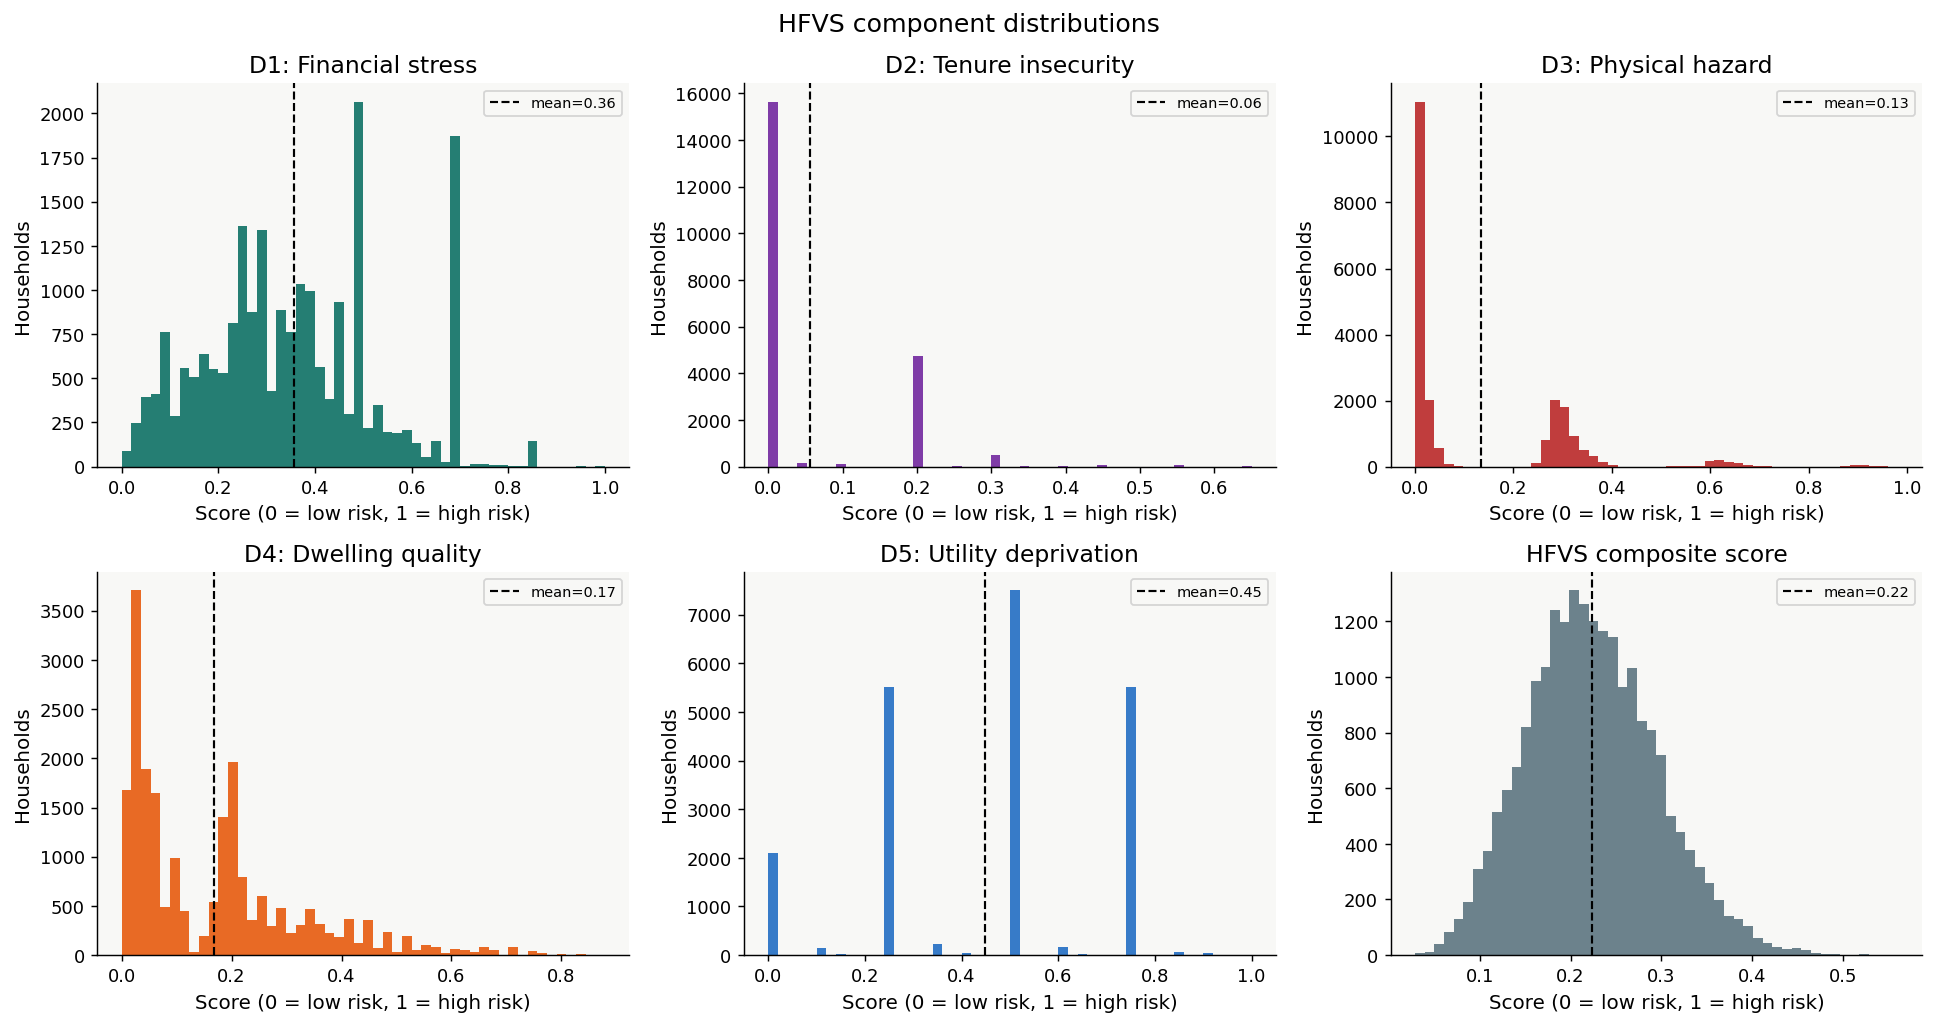

In [69]:
# ── Visualise dimension distributions ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('HFVS component distributions', fontsize=14, fontweight='500')

plot_items = [
    ('d1_financial_stress',    'D1: Financial stress',    TEAL),
    ('d2_tenure_insecurity',   'D2: Tenure insecurity',   PURPLE),
    ('d3_physical_hazard',     'D3: Physical hazard',     RED),
    ('d4_dwelling_quality',    'D4: Dwelling quality',    AMBER),
    ('d5_utility_deprivation', 'D5: Utility deprivation', BLUE),
    ('hfvs',                   'HFVS composite score',    GRAY),
]
for ax, (col, title, color) in zip(axes.flatten(), plot_items):
    ax.hist(master[col].dropna(), bins=50, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(master[col].mean(), color='black', linewidth=1.2, linestyle='--',
               label=f'mean={master[col].mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Score (0 = low risk, 1 = high risk)')
    ax.set_ylabel('Households')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / '09_hfvs_component_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

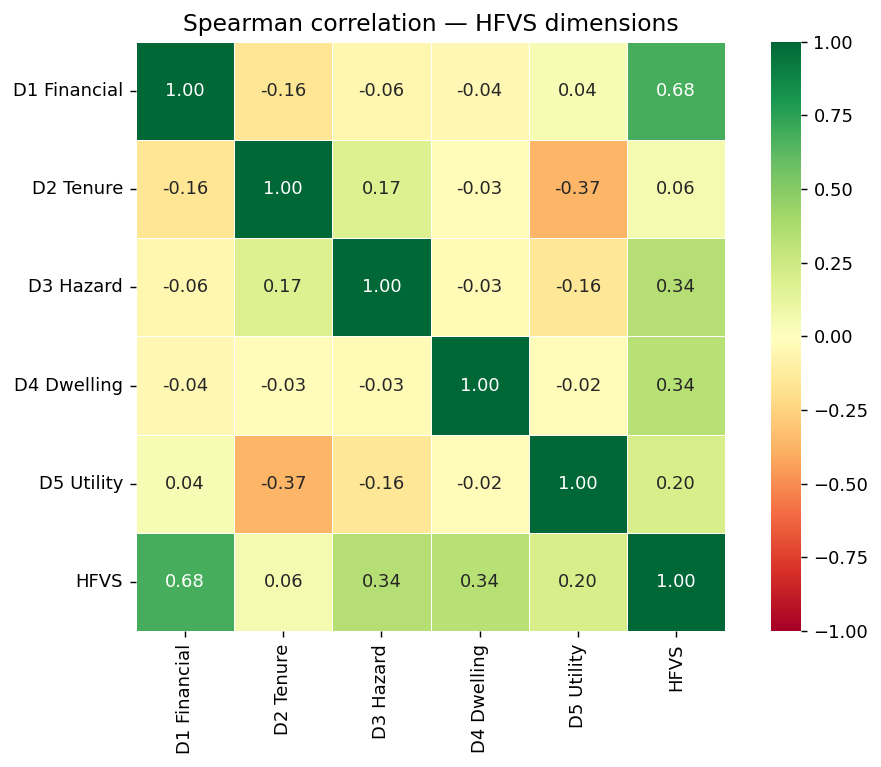


Note: High inter-dimension correlation may justify combining some dimensions
or running sensitivity analysis — document this in your methodology chapter.


In [70]:
# ── Dimension correlation heatmap ─────────────────────────────────────
dim_corr = master[dims + ['hfvs']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
short_names = ['D1 Financial','D2 Tenure','D3 Hazard','D4 Dwelling','D5 Utility','HFVS']
sns.heatmap(
    dim_corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=ax,
    xticklabels=short_names, yticklabels=short_names,
    linewidths=0.5, square=True
)
ax.set_title('Spearman correlation — HFVS dimensions')
plt.tight_layout()
plt.savefig(FIGS / '10_dimension_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: High inter-dimension correlation may justify combining some dimensions")
print("or running sensitivity analysis — document this in your methodology chapter.")

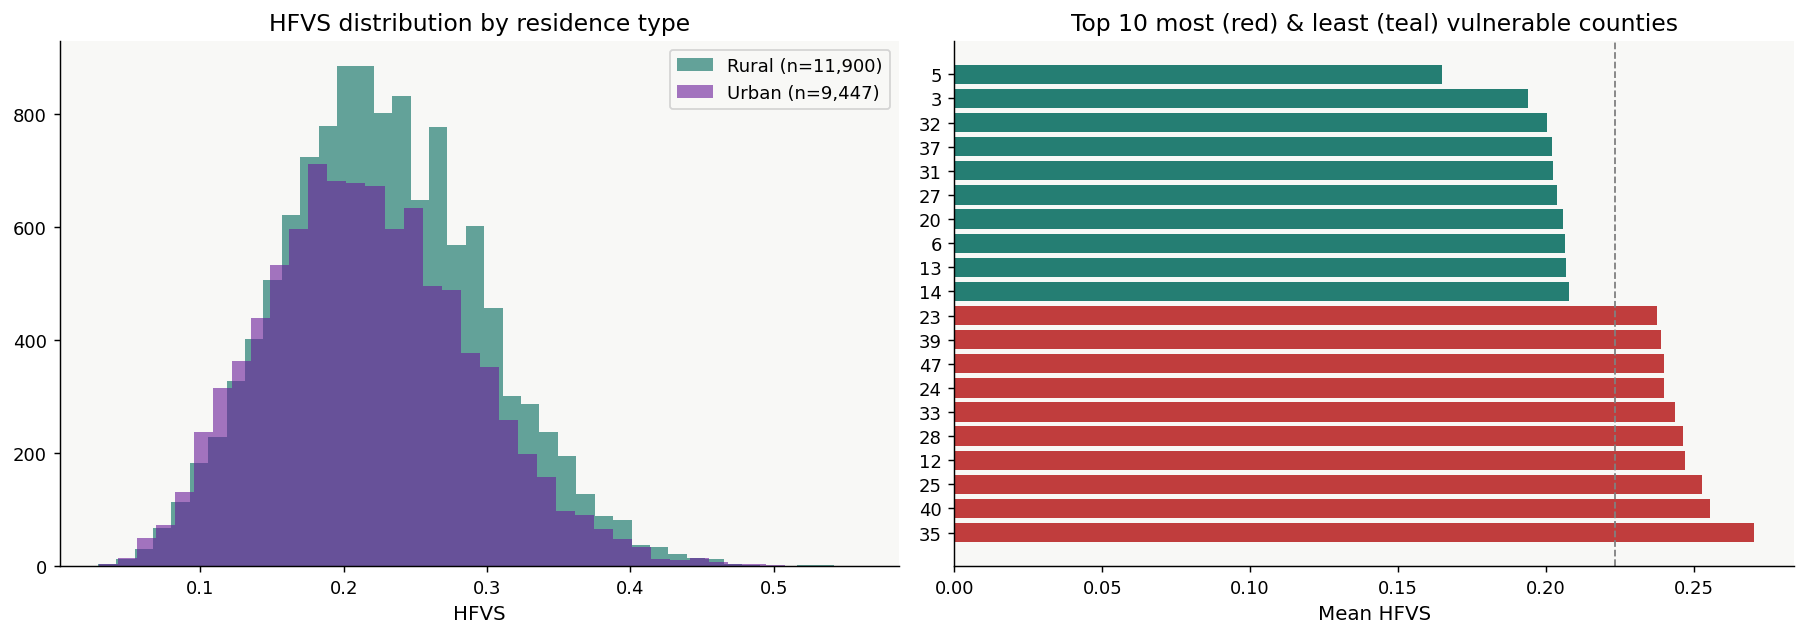

In [71]:
# ── HFVS by county and urban/rural ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Urban vs Rural
master['residence'] = master['a07_1'].map({1: 'Rural', 2: 'Urban'})
for res, color in [('Rural', TEAL), ('Urban', PURPLE)]:
    subset = master[master['residence'] == res]['hfvs']
    axes[0].hist(subset, bins=40, alpha=0.6, label=f'{res} (n={len(subset):,})',
                 color=color, edgecolor='none')
axes[0].set_title('HFVS distribution by residence type')
axes[0].set_xlabel('HFVS'); axes[0].legend()

# County mean HFVS (top 20 and bottom 20 combined)
c_hfvs = master.groupby('a01')['hfvs'].mean().sort_values(ascending=False)
display_counties = pd.concat([c_hfvs.head(10), c_hfvs.tail(10)])
colors_bar = [RED]*10 + [TEAL]*10
axes[1].barh(display_counties.index.astype(str), display_counties.values,
             color=colors_bar, edgecolor='none', alpha=0.85)
axes[1].set_title('Top 10 most (red) & least (teal) vulnerable counties')
axes[1].set_xlabel('Mean HFVS')
axes[1].axvline(master['hfvs'].mean(), color='gray', linewidth=1, linestyle='--')

plt.tight_layout()
plt.savefig(FIGS / '11_hfvs_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Additional Model Features
Supplementary features for the XGBoost model in notebook 03.

In [72]:
# ── Awareness and programme access features ────────────────────────────
# These capture households' relationship with formal housing systems

# Affordable housing awareness: j13=1 → aware
master['aware_affordable_housing'] = (
    pd.to_numeric(master.get('j13', pd.Series(0)), errors='coerce') == 1
).astype(float)

# Tax relief benefit: j18=1 → benefited
master['benefited_housing_relief'] = (
    pd.to_numeric(master.get('j18', pd.Series(0)), errors='coerce') == 1
).astype(float)

# Government rent regulation opinion: j09=1 → yes (signals awareness of affordability stress)
master['wants_rent_regulation'] = (
    pd.to_numeric(master.get('j09', pd.Series(0)), errors='coerce') == 1
).astype(float)

# Distance to health facility (access proxy from G section)
master['dist_health'] = pd.to_numeric(master.get('g01d', pd.Series(np.nan)), errors='coerce')
master['dist_health_norm'] = MinMaxScaler().fit_transform(
    master[['dist_health']].fillna(master['dist_health'].median())
).flatten()

# Internet access (digital inclusion)
master['has_internet'] = pd.to_numeric(master.get('internet', pd.Series(0)),
                                        errors='coerce').fillna(0)

# Smart security systems (c13__5) — proxy for neighbourhood quality
master['has_security_tech'] = pd.to_numeric(master.get('c13__5', pd.Series(0)),
                                             errors='coerce').fillna(0)

# Household size log-transform (for skewness)
master['log_hh_size'] = np.log1p(master['hh_size'])

# Expenditure log-transform
master['log_expenditure'] = np.log1p(master['expenditure'].fillna(0))

print("Additional features built.")
print(f"  Aware of affordable housing:  {master['aware_affordable_housing'].mean()*100:.1f}%")
print(f"  Benefited from housing relief: {master['benefited_housing_relief'].mean()*100:.1f}%")
print(f"  Wants rent regulation:         {master['wants_rent_regulation'].mean()*100:.1f}%")

Additional features built.
  Aware of affordable housing:  50.7%
  Benefited from housing relief: 0.9%
  Wants rent regulation:         39.1%


---
## 15. Final Feature Set & Master Dataset

In [73]:
# ── Full feature list for modelling ───────────────────────────────────
FEATURES_IDENTIFIERS = ['interview__key', 'a01', 'countycode', 'a07_1', 'residence', 'hhweight']

FEATURES_DIMENSIONS = [
    'd1_financial_stress', 'd2_tenure_insecurity', 'd3_physical_hazard',
    'd4_dwelling_quality', 'd5_utility_deprivation',
]

FEATURES_COMPONENT = [
    # D1
    'rent_burden', 'rent_stressed', 'severely_stressed',
    'no_savings', 'low_income_flag', 'no_loan_access',
    # D2
    'no_land_ownership', 'no_written_lease', 'rent_dispute_hist',
    'demo_neighbourhood', 'eviction_threat',
    # D3
    'flood_zone', 'mudslide_zone', 'hazard_count', 'high_risk_prox',
    # D4
    'floor_durable', 'wall_durable', 'roof_durable',
    'structural_durability', 'persons_per_room', 'overcrowded',
    # D5
    'no_electricity', 'unsafe_water', 'poor_sanitation',
    'solid_fuel', 'no_handwashing',
]

FEATURES_SUPPLEMENTARY = [
    'log_hh_size', 'hh_size', 'log_expenditure',
    'mean_age', 'dependency_ratio', 'employment_rate', 'max_edu',
    'dist_health_norm', 'has_internet',
    'aware_affordable_housing', 'wants_rent_regulation',
]

TARGETS = ['hfvs', 'hfvs_high', 'hfvs_tier', 'hfvs_equal', 'hfvs_pca']

ALL_COLS = (
    FEATURES_IDENTIFIERS + FEATURES_DIMENSIONS +
    FEATURES_COMPONENT + FEATURES_SUPPLEMENTARY + TARGETS
)
# Only keep columns that exist in master
final_cols = [c for c in ALL_COLS if c in master.columns]

master_final = master[final_cols].copy()
print(f"Master final dataset: {master_final.shape[0]:,} rows × {master_final.shape[1]} columns")
print(f"  Target variable (hfvs): mean={master_final['hfvs'].mean():.3f}")
print(f"  Binary target (hfvs_high): {master_final['hfvs_high'].mean()*100:.1f}% high vulnerability")
print(f"\nNull rates in model features:")
null_rates = master_final[FEATURES_COMPONENT + FEATURES_SUPPLEMENTARY].isna().mean() * 100
print(null_rates[null_rates > 5].sort_values(ascending=False).round(1))

Master final dataset: 21,347 rows × 53 columns
  Target variable (hfvs): mean=0.223
  Binary target (hfvs_high): 0.0% high vulnerability

Null rates in model features:
Series([], dtype: float64)


In [74]:
master_final.columns

Index(['interview__key', 'a01', 'countycode', 'a07_1', 'residence', 'hhweight',
       'd1_financial_stress', 'd2_tenure_insecurity', 'd3_physical_hazard',
       'd4_dwelling_quality', 'd5_utility_deprivation', 'rent_burden',
       'rent_stressed', 'severely_stressed', 'no_savings', 'low_income_flag',
       'no_loan_access', 'no_land_ownership', 'no_written_lease',
       'rent_dispute_hist', 'demo_neighbourhood', 'eviction_threat',
       'flood_zone', 'mudslide_zone', 'hazard_count', 'high_risk_prox',
       'floor_durable', 'wall_durable', 'roof_durable',
       'structural_durability', 'persons_per_room', 'overcrowded',
       'no_electricity', 'unsafe_water', 'poor_sanitation', 'solid_fuel',
       'no_handwashing', 'log_hh_size', 'hh_size', 'log_expenditure',
       'mean_age', 'dependency_ratio', 'employment_rate', 'max_edu',
       'dist_health_norm', 'has_internet', 'aware_affordable_housing',
       'wants_rent_regulation', 'hfvs', 'hfvs_high', 'hfvs_tier', 'hfvs_equal',
 

In [75]:
# ── County-level aggregate for Chapter 5 ──────────────────────────────
county_agg = (
    master_final
    .groupby('a01')
    .agg(
        n_households          = ('interview__key', 'count'),
        pct_urban             = ('a07_1', lambda x: (x == 2).mean() * 100),
        mean_hfvs             = ('hfvs', 'mean'),
        p75_hfvs              = ('hfvs', lambda x: x.quantile(0.75)),
        pct_high_vuln         = ('hfvs_high', 'mean'),
        mean_d1_financial     = ('d1_financial_stress', 'mean'),
        mean_d2_tenure        = ('d2_tenure_insecurity', 'mean'),
        mean_d3_hazard        = ('d3_physical_hazard', 'mean'),
        mean_d4_dwelling      = ('d4_dwelling_quality', 'mean'),
        mean_d5_utility       = ('d5_utility_deprivation', 'mean'),
        pct_flood             = ('flood_zone', 'mean'),
        pct_no_electricity    = ('no_electricity', 'mean'),
        pct_rent_stressed     = ('rent_stressed', 'mean'),
        pct_eviction          = ('eviction_threat', 'mean'),
        mean_expenditure      = ('log_expenditure', 'median'),
    )
    .reset_index()
    .sort_values('mean_hfvs', ascending=False)
)

county_agg.to_csv(TABLES / 'county_hfvs_profile.csv', index=False)
print(f"County HFVS profile: {county_agg.shape}")
print(county_agg[['a01','mean_hfvs','pct_high_vuln','pct_urban']].head(15).round(3).to_string())

County HFVS profile: (47, 16)
    a01  mean_hfvs  pct_high_vuln  pct_urban
34   35      0.270            0.0     34.146
39   40      0.256            0.0     32.524
24   25      0.253            0.0     40.795
11   12      0.247            0.0     32.524
27   28      0.246            0.0     32.225
32   33      0.244            0.0     39.666
23   24      0.240            0.0     38.104
46   47      0.240            0.0    100.000
38   39      0.239            0.0     37.879
22   23      0.238            0.0     44.022
25   26      0.236            0.0     39.142
3     4      0.235            0.0     46.667
7     8      0.234            0.0     40.816
10   11      0.231            0.0     47.463
21   22      0.230            0.0     49.843


In [76]:
# ── Save master dataset ────────────────────────────────────────────────
out_path = DRIVE / 'data' / 'parquet' / 'master_hfvs.parquet'
pl.from_pandas(master_final).write_parquet(out_path)
size_mb = out_path.stat().st_size / 1e6

print(f"Saved: {out_path}")
print(f"  Size: {size_mb:.2f} MB")
print(f"  Rows: {master_final.shape[0]:,}")
print(f"  Cols: {master_final.shape[1]}")
print(f"\nThis file is the sole input to notebook 03 (model training).")

# Also save feature lists for notebook 03
feature_registry = {
    'identifiers':   FEATURES_IDENTIFIERS,
    'dimensions':    FEATURES_DIMENSIONS,
    'component':     [c for c in FEATURES_COMPONENT if c in master_final.columns],
    'supplementary': [c for c in FEATURES_SUPPLEMENTARY if c in master_final.columns],
    'targets':       TARGETS,
    'weighting_note': {
        'primary':     'hfvs_lit (literature-informed weights)',
        'alternative': ['hfvs_equal', 'hfvs_pca'],
        'lit_weights': LIT_WEIGHTS,
        'pca_weights': dict(zip(dims, pca_weights.tolist())),
    }
}
with open(TABLES / 'feature_registry.json', 'w') as f:
    json.dump(feature_registry, f, indent=2)
print("Feature registry saved to outputs/tables/feature_registry.json")

Saved: /content/drive/MyDrive/KHS_Dissertation/data/parquet/master_hfvs.parquet
  Size: 1.16 MB
  Rows: 21,347
  Cols: 53

This file is the sole input to notebook 03 (model training).
Feature registry saved to outputs/tables/feature_registry.json


In [77]:
# Confirm individual codebook — education and employment columns
with open(PQ / 'individual_variable_labels.json') as f:
    ind_labels = json.load(f)

for col, lbl in ind_labels.items():
    if any(k in lbl.lower() for k in ['employ', 'work', 'education', 'school', 'literate']):
        print(f"{col:<20} → {lbl}")

b10                  → B10:Has [NAME] ever attended school?
b11                  → B11:Is [NAME] currently attending School/ Academic institution?
b13                  → B13:What  is the highest education level completed
b13_other            → B13_Other:What  is the highest education level completed
b13_2                → B13_2:Mode of transport used to school
b13_2_other          → B13_2_Other:Mode of transport used to school
wap_1                → Working age population defined
age_cohort           → Working Age Population 15-64
ken_edu_isced11      → Highest Education Level Completed 
ken_edu_attendance   → Education (Attendance)
edu_attendance       → Current Education level 


In [78]:
# Confirm d16 code 3 label
dw_val = json.load(open(PQ / 'dwelling_value_labels.json'))
print("Roof material labels (d16):")
for k, v in dw_val.get('D16', dw_val.get('d16', {})).items():
    print(f"  {k} → {v}")

Roof material labels (d16):
  1 → Grass / Makuti thatch/twigs
  2 → Dung / mud
  3 → Iron sheets/Decra/Versatile
  4 → Tin cans
  5 → Asbestos sheet
  6 → Concrete/Cement
  7 → Tiles
  8 → Canvas/Nylon/Cartons/Cardboard
  96 → Other


In [79]:
# Search broader terms
for col, lbl in ind_labels.items():
    if any(k in lbl.lower() for k in ['b09', 'job', 'earn', 'occupation',
                                        'paid', 'labour', 'labor', 'activity']):
        nn = ind[col].notna().sum() if col in ind.columns else '—'
        print(f"{col:<20} → {lbl}  [{nn}]")

# Also just print all b09 columns directly
print("\nAll b09 columns:")
for col in [c for c in ind.columns if 'b09' in c or 'wap' in c]:
    print(f"  {col:<20} → {ind_labels.get(col,'?')}  vals={ind[col].value_counts().head(3).to_dict()}")

b09_1                → B09_1:County of birth  [80882]
b09_2                → B09_2:Country of birth  [253]
b09_3                → B09_3 been living continuously  [80887]
b09_4                → B09_4:In which year did [NAME] move to this COUNTY or country?  [12879]
b09_5                → B09_5:Just before [NAME] moved here, which County did he/she live in?  [12877]
b09_6                → B09_6  [12876]
b09_7                → B09_7:Main reason for moving  [12875]
b09_7other           → B09_7Other:Main reason for moving other  [80889]

All b09 columns:
  b09_1                → B09_1:County of birth  vals={9.0: 2859, 8.0: 2654, 10.0: 2473}
  b09_2                → B09_2:Country of birth  vals={233.0: 78, 220.0: 46, 71.0: 34}
  b09_3                → B09_3 been living continuously  vals={-1.0: 67903, 0.0: 994, 3.0: 910}
  b09_4                → B09_4:In which year did [NAME] move to this COUNTY or country?  vals={2023.0: 1158, 2019.0: 919, 2021.0: 846}
  b09_5                → B09_5:Just be

---
## 16. Push to GitHub

In [80]:
!git config user.email "gronjerono@gmail.com"
!git config user.name "VAL-Jerono"

!git add notebooks/02_feature_engineering.ipynb
!git add outputs/figures/ outputs/tables/ 2>/dev/null || true
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [81]:
!git commit -m "feat: feature engineering complete — HFVS 5-dimension composite score, master_hfvs.parquet"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
